![image.png](https://i.imgur.com/a3uAqnb.png)

# 🎥 UCF101 Video Classification Using 3D ResNet - Homework Assignment

In this homework, you will fine tune a **3D ResNet model for video classification** to recognize human actions from short video clips. This project is designed to give you practical experience working with spatiotemporal data using deep learning.

## 📌 Project Overview
- **Task**: Classify human actions from video clips
- **Architecture**: 3D ResNet for video classification
- **Dataset**: UCF101 action recognition dataset
- **Goal**: Build an accurate classification model using PyTorch

## 📚 Learning Objectives
By completing this assignment, you will:
- Learn how to process and sample frames from video files
- Fine tune a 3D ResNet model using PyTorch
- Train and evaluate models on the UCF101 dataset
- Analyze model performance on real-world video data

## 📦 Dataset Details
- The **UCF101** dataset contains 13,320 training videos across 101 action categories
- Each video clip captures a single action performed by a human in various environments
- Videos are processed into fixed-length clips (e.g., 16 or 32 frames) for training

## 🏷️ Labels Representation
- Each video is labeled with a class index from `0` to `100`
- Example classes include:
  - `Basketball`
  - `Horse Riding`
  - `Ice Dancing`
  - `Playing Guitar`
  - `Volleyball Spiking`

## 🔗 Reference
Original dataset link: [UCF101 Kaggle Dataset](https://www.kaggle.com/datasets/pevogam/ucf101)


## 1️⃣ Initial Setup and Library Installation

**Task**: Set up the environment and install necessary libraries.

In [ ]:
from IPython.display import clear_output
# In case you run this notebook outside colab (where the libraries aren't already pre-installed)

#%pip install torch
#%pip install matplotlib
#%pip install scikit-learn
#%pip install pandas
#%pip install numpy
# %pip install opencv-python

clear_output()

## 2️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up configuration parameters.

**Requirements**:
- Import PyTorch and 3D ResNet model
- Import data processing libraries (pandas, sklearn, cv2)
- Import visualization libraries
- Set random seeds for reproducibility
- Configure hyperparameters with reasonable values

In [ ]:
# Imports
import os
import cv2
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch.nn.functional as F
import sklearn as sk

import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import v2 as T
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.models.video import r3d_18, R3D_18_Weights
from tqdm.auto import tqdm

import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import kagglehub


# Setup & Configuration

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Hyperparameters for Two-Phase Training

# General
BATCH_SIZE = 16          # Batch size (can be increased with a powerful GPU)
FRAMES_PER_CLIP = 16     # Number of frames to sample per video
NUM_CLASSES = 101        # Number of action classes in UCF101
IMAGE_SIZE = 128         # Resize frames to this size

# Phase 1: Train the classifier head
HEAD_ONLY_EPOCHS = 2     # Epochs to train only the head
LR_HEAD = 1e-3           # Learning rate for the head

# Phase 2: Fine-tune the entire model
FULL_FINETUNE_EPOCHS = 3 # Epochs to fine-tune the full model
LR_FULL = 1e-5           # A smaller learning rate for fine-tuning

# Data Splits
VALIDATION_SPLIT = 0.2   # Validation split ratio (20%)
TEST_SPLIT = 0.2         # Test split ratio (20%)

Using device: cuda


## 3️⃣ Data Loading and Exploration

**Task**: Download the UCF101 dataset and explore its structure.

**Requirements**:
- Download and load the dataset
- Display basic information about the data
- Load class mappings and video file paths
- Understand the dataset structure and labels

In [ ]:
# Download dataset
path = kagglehub.dataset_download("pevogam/ucf101")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ucf101


In [ ]:
# Load class name to index
classInd_txt = path + "/UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/classInd.txt"
cls_df = pd.read_csv(classInd_txt, sep=" ", header=None,
                        names=["index", "class_name"])
cls_df.head()


,index,class_name
0,1,ApplyEyeMakeup
1,2,ApplyLipstick
2,3,Archery
3,4,BabyCrawling
4,5,BalanceBeam


In [ ]:
# Create class_to_idx and idx_to_class dictionaries
# The original classInd.txt is 1-indexed, so we subtract 1 for 0-indexed labels
class_to_idx = {name: index - 1 for index, name in zip(cls_df['index'], cls_df['class_name'])}
idx_to_class = {index - 1: name for index, name in zip(cls_df['index'], cls_df['class_name'])}

# Print dataset information
print(f"There are {len(class_to_idx)} classes.")
print("\nClass to Index Mapping (sample):")
print({k: class_to_idx[k] for k in list(class_to_idx)[:5]})
# verify inverse mapping
print("\nIndex to Class Mapping (sample):")
print({k: idx_to_class[k] for k in list(idx_to_class)[:5]})

There are 101 classes.

Class to Index Mapping (sample):
{'ApplyEyeMakeup': 0, 'ApplyLipstick': 1, 'Archery': 2, 'BabyCrawling': 3, 'BalanceBeam': 4}

Index to Class Mapping (sample):
{0: 'ApplyEyeMakeup', 1: 'ApplyLipstick', 2: 'Archery', 3: 'BabyCrawling', 4: 'BalanceBeam'}


In [ ]:
# Load video paths and labels from the training split file
videos_root = os.path.join(path, "UCF101/UCF-101")
paths_file = os.path.join(path, "UCF101TrainTestSplits-RecognitionTask/ucfTrainTestlist/trainlist01.txt")

# Initialize lists for videos and labels
all_videos = []
all_labels = []

# Read training list file and extract video paths and labels
with open(paths_file, 'r') as f:
    for line in f:
        # Each line is in the format "ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi 1"
        # We can ignore the provided index and get it from the path
        video_path_relative, _ = line.strip().split()
        class_name = video_path_relative.split('/')[0]

        # Construct full path
        full_video_path = os.path.join(videos_root, video_path_relative)

        all_videos.append(full_video_path)
        all_labels.append(class_to_idx[class_name])


# Print total videos loaded
print(f"Total videos loaded: {len(all_videos)}")

Total videos loaded: 9537


## 4️⃣ Data Preprocessing & Dataset Creation & data showing

**Task**: Create custom dataset class and prepare data splits.

**Requirements**:
- Implement video reading and frame sampling
- Create custom PyTorch Dataset class
- Split data into train/validation/test sets
- Apply appropriate transformations
- Create data loaders for batch processing
- Visualize clips of a video
- Show a video

In [ ]:
def read_video_opencv(video_path, frames_per_clip=16, resize=(IMAGE_SIZE, IMAGE_SIZE)):
    """
    Reads a video file, samples frames evenly, resizes them, and returns a tensor.
    """
    # Open video using cv2.VideoCapture
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    # Get total number of frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []

    # Calculate frame indices to sample evenly
    if total_frames > 0:
        indices = np.linspace(0, total_frames - 1, frames_per_clip, dtype=int)

        # Read frames and convert BGR to RGB
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_resized = cv2.resize(frame_rgb, resize)
                frames.append(frame_resized)
            else:
                # If reading a frame fails, append the last successful one
                if frames:
                    frames.append(frames[-1])

    # Close video capture
    cap.release()

    # Pad frames if the video was too short
    while len(frames) < frames_per_clip:
        if not frames:
            # If the video was empty, append black frames
            frames.append(np.zeros((resize[0], resize[1], 3), dtype=np.uint8))
        else:
            # Otherwise, pad with the last available frame
            frames.append(frames[-1])

    # Convert to tensor and rearrange dimensions to (C, T, H, W)
    frames_np = np.array(frames)
    clip_tensor = torch.from_numpy(frames_np)
    clip_tensor = clip_tensor.permute(3, 0, 1, 2) # From (T, H, W, C) to (C, T, H, W)

    return clip_tensor

In [ ]:
class UCF101Dataset(Dataset):
    def __init__(self, videos, labels, transform=None, frames_per_clip=16):
        self.videos = videos
        self.labels = labels
        self.transform = transform
        self.frames_per_clip = frames_per_clip

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video_path = self.videos[idx]
        label = self.labels[idx]
        clip = read_video_opencv(video_path, self.frames_per_clip)

        if self.transform:
            clip = clip.permute(1, 0, 2, 3)
            clip = self.transform(clip)
            clip = clip.permute(1, 0, 2, 3)
        return clip, torch.tensor(label, dtype=torch.long)

In [ ]:
# --- Data Augmentation and Transformation ---

# Define augmentations for the training set
train_transform = T.Compose([
    T.ToDtype(torch.float32, scale=True),        # Convert to float and scale to [0, 1]
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Define transformations for validation and test sets (no augmentation)
val_transform = T.Compose([
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Split data into train/validation/test sets
train_videos, temp_videos, train_labels, temp_labels = train_test_split(
    all_videos, all_labels,
    test_size=(VALIDATION_SPLIT + TEST_SPLIT), random_state=SEED, stratify=all_labels
)
relative_test_split = TEST_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)
val_videos, test_videos, val_labels, test_labels = train_test_split(
    temp_videos, temp_labels,
    test_size=relative_test_split, random_state=SEED, stratify=temp_labels
)

# Create dataset instances
train_dataset = UCF101Dataset(train_videos, train_labels, transform=train_transform, frames_per_clip=FRAMES_PER_CLIP)
val_dataset = UCF101Dataset(val_videos, val_labels, transform=val_transform, frames_per_clip=FRAMES_PER_CLIP)
test_dataset = UCF101Dataset(test_videos, test_labels, transform=val_transform, frames_per_clip=FRAMES_PER_CLIP)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size: {len(train_dataset)} | Validation size: {len(val_dataset)} | Test size: {len(test_dataset)}")


Train size: 5722 | Validation size: 1907 | Test size: 1908


In [ ]:
# Test data loader by getting one batch
videos_batch, labels_batch = next(iter(train_loader))

# Print batch shape and labels
print("--- Batch from DataLoader ---")
print(f"Batch of videos shape: {videos_batch.shape}")
print(f"Batch of labels: {labels_batch}")
print("-" * 30)

# Get one sample from training dataset
sample_video, sample_label = train_dataset[0]

# Print sample video shape and label with class name
print("\n--- Single Sample from Dataset ---")
print(f"Sample video shape: {sample_video.shape}")
# Use .item() to extract the integer value from the label tensor
label_index = sample_label.item()
print(f"Sample label index: {label_index}")
# Look up the class name using the index
print(f"Sample label class name: {idx_to_class[label_index]}")
print("-" * 30)

--- Batch from DataLoader ---
Batch of videos shape: torch.Size([16, 3, 16, 128, 128])
Batch of labels: tensor([28, 20, 31,  0, 33, 44, 21,  8, 67,  9, 72, 21, 39, 77, 79,  2])
------------------------------

--- Single Sample from Dataset ---
Sample video shape: torch.Size([3, 16, 128, 128])
Sample label index: 44
Sample label class name: JavelinThrow
------------------------------


In [ ]:
def show_video_clip(tensor_clip, label='', fps=None):
    """
    Display a (C, T, H, W) tensor as an animation inline with a label.
    Assumes the input tensor is already in the [0, 1] range for visualization.

    Parameters:
      tensor_clip (Tensor): A tensor of shape (C, T, H, W) with values in [0, 1].
      label (str): Text label to display (e.g., class name)
      fps (int): Frames per second. If None, defaults to T (one second playback)
    """
    # Permute from (C, T, H, W) to (T, H, W, C)
    clip = tensor_clip.permute(1, 2, 3, 0) # Shape (T, H, W, C)

    # Convert to numpy for visualization
    # Multiply by 255 and convert to uint8 as matplotlib expects 0-255
    clip_np = (clip.cpu().numpy() * 255).astype(np.uint8)

    if fps is None:
        fps = clip_np.shape[0]  # Use T as default fps

    fig, ax = plt.subplots()
    ax.set_title(label)
    im = ax.imshow(clip_np[0])

    def update(frame_idx):
        im.set_array(clip_np[frame_idx])
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=clip_np.shape[0], interval=1000 // fps, blit=True)
    plt.close(fig)

    video_html = ani.to_html5_video()
    video_html = video_html.replace("controls>", "controls autoplay muted>")
    return HTML(video_html)

In [ ]:
# To properly visualize, we need a clip that isn't normalized
# We'll create a temporary dataset instance without the validation/test transform.
vis_dataset = UCF101Dataset(test_videos, test_labels, transform=None, frames_per_clip=FRAMES_PER_CLIP)

# Get a random index to select a video from the test set
random_idx = random.randint(0, len(vis_dataset) - 1)
clip_to_show, label_to_show = vis_dataset[random_idx]

# The output from read_video_opencv is a float tensor with values from 0-255.
# We need to scale it to the [0, 1] range for correct display.
clip_to_show = clip_to_show / 255.0

# Get the corresponding class name for the label
class_name = idx_to_class[label_to_show.item()]

print(f"Displaying a random clip from the test set.")
print(f"Class: {class_name}")

# Show the video using the pre-defined helper function
show_video_clip(clip_to_show, label=class_name)

Displaying a random clip from the test set.
Class: WallPushups


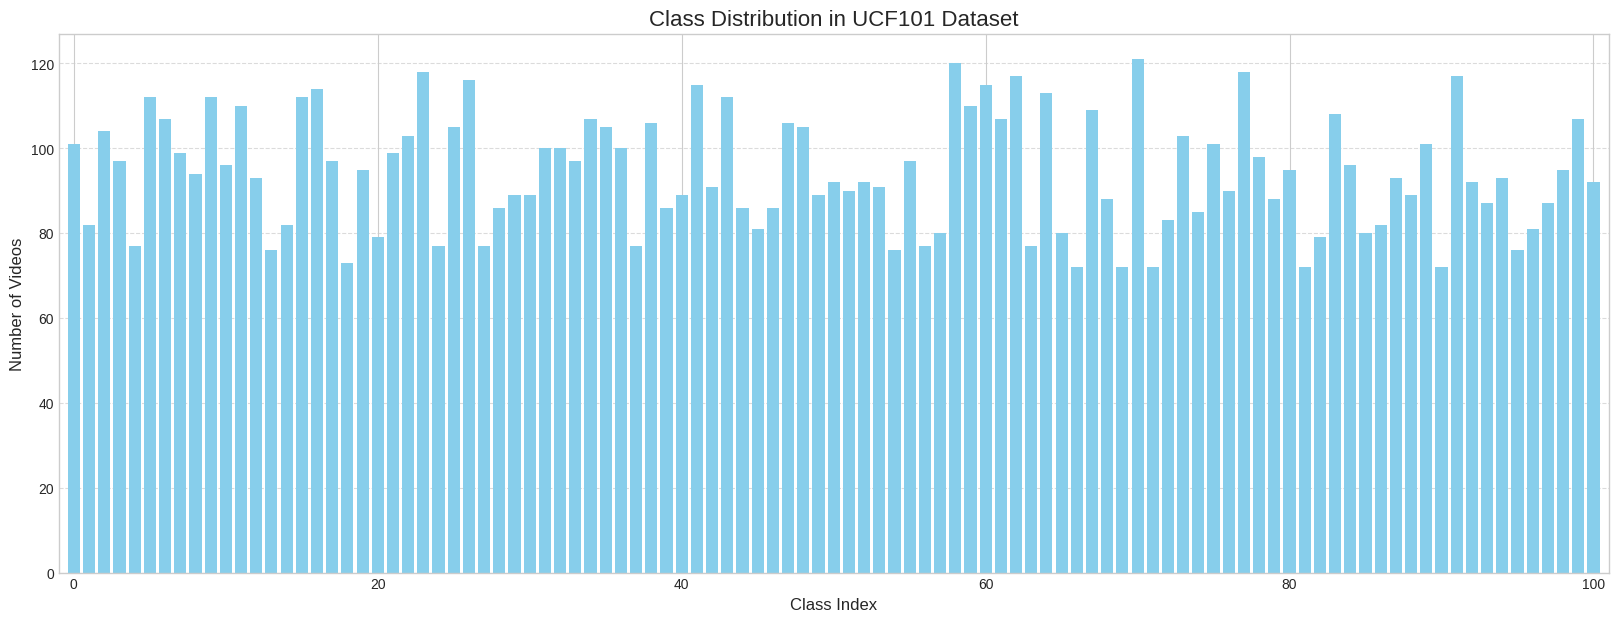

In [ ]:
# --- EDA: Plotting Class Distribution ---
# Count the occurrences of each class label
label_counts = pd.Series(all_labels).value_counts().sort_index()

# Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 7))
plt.bar(label_counts.index, label_counts.values, color='skyblue')

# Add titles and labels
plt.title('Class Distribution in UCF101 Dataset', fontsize=16)
plt.xlabel('Class Index', fontsize=12)
plt.ylabel('Number of Videos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-1, NUM_CLASSES) # Set x-axis limits to show all classes
plt.show()

Analyzing frame counts for a random sample of 500 videos...


Processing videos:   0%|          | 0/500 [00:00<?, ?it/s]

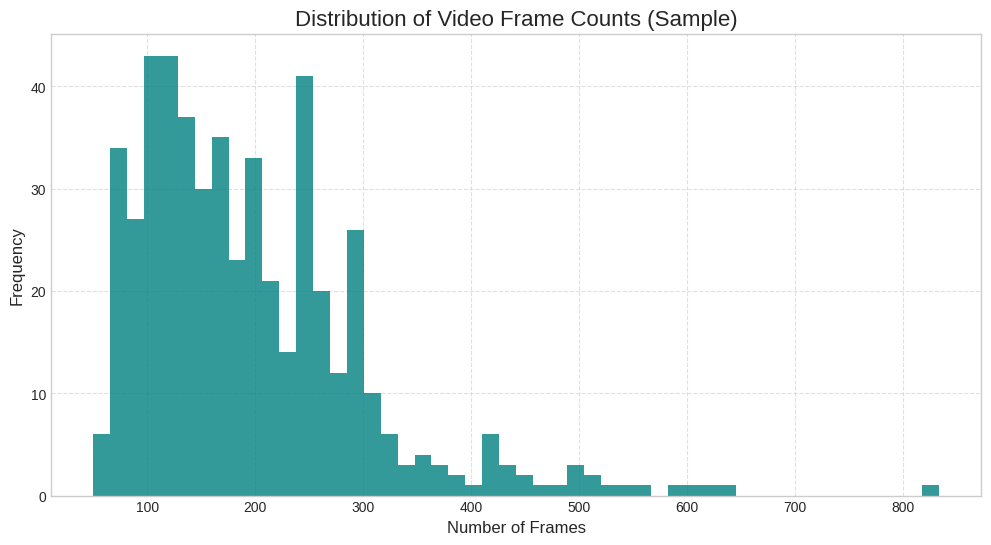

In [ ]:
# --- EDA: Analyzing Video Lengths ---
frame_counts = []
sample_size = 500
print(f"Analyzing frame counts for a random sample of {sample_size} videos...")

# Randomly sample video paths for efficiency
sampled_videos = random.sample(all_videos, sample_size)

for video_path in tqdm(sampled_videos, desc="Processing videos"):
    cap = cv2.VideoCapture(video_path)
    if cap.isOpened():
        count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_counts.append(count)
    cap.release()

# Plotting the distribution
plt.figure(figsize=(12, 6))
plt.hist(frame_counts, bins=50, color='teal', alpha=0.8)
plt.title('Distribution of Video Frame Counts (Sample)', fontsize=16)
plt.xlabel('Number of Frames', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5️⃣ Model Architecture and Fine-Tuning Setup

**Task**: Set up 3D ResNet model for fine-tuning and define training functions.

**Requirements**:
- Load pre-trained 3D ResNet model
- Modify final layer for UCF101 classes
- Define training and evaluation functions
- Implement metrics calculation

In [ ]:
from torchvision.models.video import r3d_18, R3D_18_Weights

# Load the pre-trained r3d_18 model
pretrained_model = r3d_18(weights=R3D_18_Weights.DEFAULT)

# Print the model's architecture
print(pretrained_model)

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth
100%|██████████| 127M/127M [00:00<00:00, 216MB/s]


VideoResNet(
  (stem): BasicStem(
    (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (conv2): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1):

In [ ]:
def build_model(num_classes, freeze_backbone=True):
    """
    Builds the R3D_18 model.

    Args:
        num_classes (int): Number of output classes.
        freeze_backbone (bool): If True, freezes the convolutional layers.
    """
    # Load pre-trained r3d_18 model
    model = r3d_18(weights=R3D_18_Weights.DEFAULT)

    # Freeze backbone layers if specified
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final fully connected layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model

def compute_metrics(preds, labels):
    """Calculates accuracy, precision, recall, and F1 score."""
    labels_cpu = labels.cpu().numpy()
    preds_cpu = preds.detach().cpu()
    predicted_labels = torch.argmax(preds_cpu, dim=1).numpy()

    acc = accuracy_score(labels_cpu, predicted_labels)
    precision = precision_score(labels_cpu, predicted_labels, average='macro', zero_division=0)
    recall = recall_score(labels_cpu, predicted_labels, average='macro', zero_division=0)
    f1 = f1_score(labels_cpu, predicted_labels, average='macro', zero_division=0)

    return {'accuracy': acc*100, 'precision': precision*100, 'recall': recall*100, 'f1_score': f1*100}

## 6️⃣ Training and Validation Functions

**Task**: Implement comprehensive training and validation loops.

**Requirements**:
- Define training loop with gradient computation
- Implement validation loop with metrics tracking
- Monitor training progress with appropriate metrics

In [ ]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """Runs a single training epoch."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    for videos, labels in progress_bar:
        videos, labels = videos.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_preds.append(outputs)
        all_labels.append(labels)
        progress_bar.set_postfix(loss=loss.item())
    avg_loss = total_loss / len(train_loader)
    metrics = compute_metrics(torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, metrics

@torch.no_grad()
def evaluate(model, val_loader, criterion, device):
    """Runs a single evaluation epoch."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    progress_bar = tqdm(val_loader, desc="Evaluating", leave=False)
    for videos, labels in progress_bar:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        all_preds.append(outputs)
        all_labels.append(labels)
    avg_loss = total_loss / len(val_loader)
    metrics = compute_metrics(torch.cat(all_preds), torch.cat(all_labels))
    return avg_loss, metrics

# Define loss function
criterion = nn.CrossEntropyLoss()

## 7️⃣ Training Loop with Validation

**Task**: Execute the complete training process with validation monitoring.

**Requirements**:
- Train model for specified epochs
- Track training and validation metrics
- Save best model based on validation performance
- Display training progress

In [ ]:
# Main Training Loop
# --------------------------------------------------------
#
# Build the initial model (backbone frozen)
model = build_model(NUM_CLASSES, freeze_backbone=True).to(device)
print(f"Model loaded on {device}")

# History tracking
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc = 0

# --- PHASE 1: TRAIN THE HEAD ---
print("\n--- Starting Phase 1: Training Classifier Head ---")
optimizer = optim.Adam(model.fc.parameters(), lr=LR_HEAD)
scheduler = CosineAnnealingLR(optimizer, T_max=HEAD_ONLY_EPOCHS, eta_min=1e-6)

for epoch in range(HEAD_ONLY_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{HEAD_ONLY_EPOCHS}")
    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['lr'].append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['accuracy']:.2f}%")
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved with validation accuracy: {best_val_acc:.2f}%")

# --- PHASE 2: UNFREEZE AND FINE-TUNE ALL LAYERS ---
print("\n--- Starting Phase 2: Fine-tuning Full Model ---")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=LR_FULL)
scheduler = CosineAnnealingLR(optimizer, T_max=FULL_FINETUNE_EPOCHS, eta_min=1e-7)

for epoch in range(FULL_FINETUNE_EPOCHS):
    print(f"\nEpoch {epoch + 1 + HEAD_ONLY_EPOCHS}/{HEAD_ONLY_EPOCHS + FULL_FINETUNE_EPOCHS}")
    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_metrics = evaluate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['lr'].append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['accuracy']:.2f}%")
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved with validation accuracy: {best_val_acc:.2f}%")

print("\nTraining complete!")



Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth
100%|██████████| 127M/127M [00:03<00:00, 43.8MB/s]


Model loaded on cuda

--- Starting Phase 1: Training Classifier Head ---

Epoch 1/2


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

Train Loss: 2.7400 | Val Loss: 1.0945 | Val Acc: 82.64%
New best model saved with validation accuracy: 82.64%

Epoch 2/2


...

Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

Train Loss: 0.3884 | Val Loss: 0.2857 | Val Acc: 95.18%
New best model saved with validation accuracy: 95.18%

Epoch 5/5


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

Train Loss: 0.3049 | Val Loss: 0.2629 | Val Acc: 95.54%
New best model saved with validation accuracy: 95.54%

Training complete!


## 8️⃣ Model Evaluation and Testing

**Task**: Evaluate the trained model on the test set and calculate classification metrics.

**Requirements**:
- Load best model for testing
- Make predictions on test set
- Calculate comprehensive classification metrics
- Analyze model performance

In [ ]:
# Load the best model saved during training
model.load_state_dict(torch.load('best_model.pth', map_location=device))
print("Best model loaded for final testing.")

# Evaluate on the unseen test set
test_loss, test_metrics = evaluate(model, test_loader, criterion, device)

# Print comprehensive test results
print("\n--- Test Set Evaluation ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.2f}%")
print(f"Test Precision: {test_metrics['precision']:.2f}%")
print(f"Test Recall: {test_metrics['recall']:.2f}%")
print(f"Test F1-Score: {test_metrics['f1_score']:.2f}%")

Best model loaded for final testing.


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]


--- Test Set Evaluation ---
Test Loss: 0.2622
Test Accuracy: 95.70%
Test Precision: 95.89%
Test Recall: 95.48%
Test F1-Score: 95.49%


## 9️⃣ Visualization and Analysis

**Task**: Create visualizations to analyze model performance and training progress.

**Requirements**:
- Plot training and validation loss curves
- Display sample predictions with confidence scores
- Analyze model performance across different classes

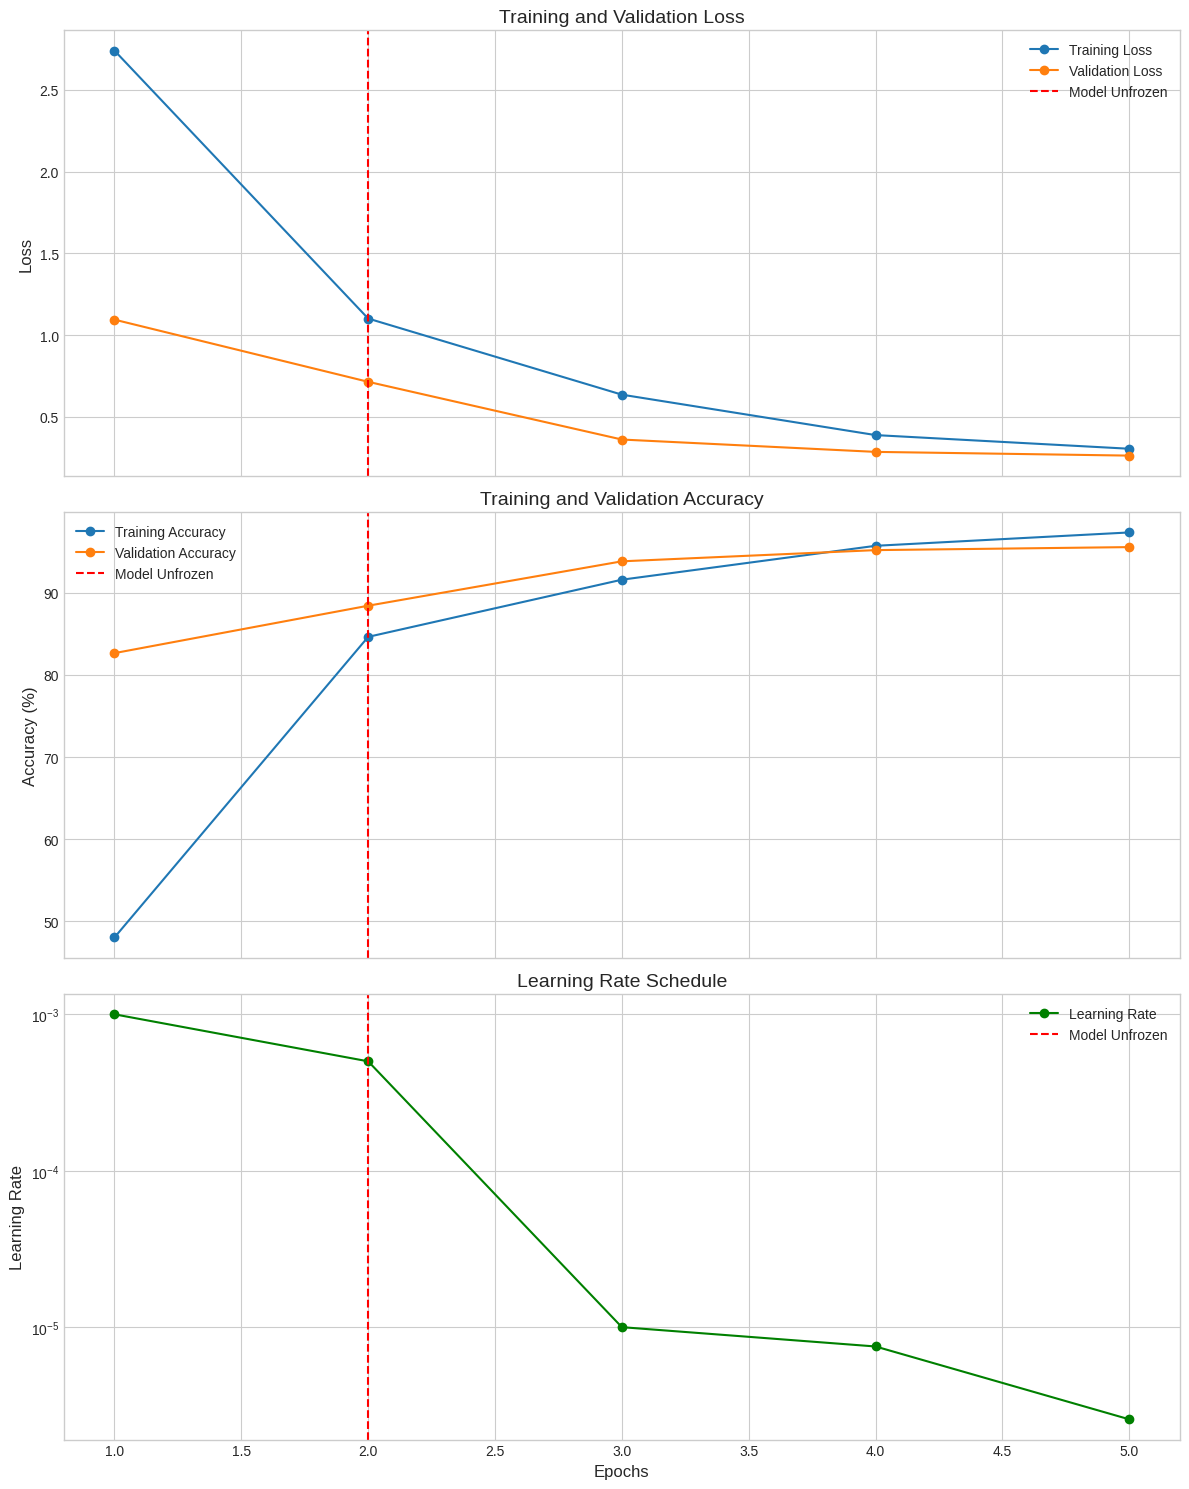

In [ ]:
# --- Visualization of Training History ---
total_epochs = HEAD_ONLY_EPOCHS + FULL_FINETUNE_EPOCHS
epochs_range = range(1, total_epochs + 1)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Plot Loss
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Training Loss')
ax1.plot(epochs_range, history['val_loss'], 'o-', label='Validation Loss')
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.axvline(x=HEAD_ONLY_EPOCHS, linestyle='--', color='r', label='Model Unfrozen')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs_range, history['train_acc'], 'o-', label='Training Accuracy')
ax2.plot(epochs_range, history['val_acc'], 'o-', label='Validation Accuracy')
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.axvline(x=HEAD_ONLY_EPOCHS, linestyle='--', color='r', label='Model Unfrozen')
ax2.legend()

# Plot Learning Rate
ax3.plot(epochs_range, history['lr'], 'o-', label='Learning Rate', color='green')
ax3.set_ylabel('Learning Rate', fontsize=12)
ax3.set_xlabel('Epochs', fontsize=12)
ax3.set_title('Learning Rate Schedule', fontsize=14)
ax3.set_yscale('log')
ax3.axvline(x=HEAD_ONLY_EPOCHS, linestyle='--', color='r', label='Model Unfrozen')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Visualization of Sample Predictions ---
# We use the 'vis_dataset' created earlier, which provides raw, untransformed video clips.
def show_sample_prediction(model, vis_dataset, idx_to_class, device, transform):
    """
    Selects a random video, gets the model's prediction, and displays
    the video with the true and predicted labels.
    """
    model.eval()
    with torch.no_grad():
        # Get a random raw clip and its label from the visualization dataset
        idx = random.randint(0, len(vis_dataset) - 1)
        clip_raw, true_label_idx = vis_dataset[idx] # This is a (C, T, H, W) uint8 tensor
        true_label_name = idx_to_class[true_label_idx.item()]

        # Prepare the clip for the model by applying the validation transform
        # The transform expects (T, C, H, W) so we permute
        clip_for_model = clip_raw.permute(1, 0, 2, 3)
        clip_for_model = transform(clip_for_model) # Applies ToDtype, scale, and Normalize
        clip_for_model = clip_for_model.permute(1, 0, 2, 3) # Permute back for the model

        # Make prediction
        clip_batch = clip_for_model.unsqueeze(0).to(device)
        output = model(clip_batch)
        probs = F.softmax(output, dim=1)

        # Get top prediction
        confidence, predicted_idx = torch.max(probs, 1)
        predicted_label_name = idx_to_class[predicted_idx.item()]

        # Prepare the clip for display (scale raw clip to [0, 1])
        clip_for_display = clip_raw / 255.0

        label_text = f"True: {true_label_name} | Pred: {predicted_label_name} ({confidence.item()*100:.1f}%)"
        print(label_text)
        return show_video_clip(clip_for_display, label=label_text)

# Display 3 sample predictions
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    display(show_sample_prediction(model, vis_dataset, idx_to_class, device, val_transform))



--- Sample 1 ---
True: JavelinThrow | Pred: JavelinThrow (87.9%)



--- Sample 2 ---
True: HammerThrow | Pred: HammerThrow (90.9%)



--- Sample 3 ---
True: Skijet | Pred: Skijet (67.3%)


Generating predictions for the test set to create the confusion matrix...


Getting Test Predictions:   0%|          | 0/120 [00:00<?, ?it/s]

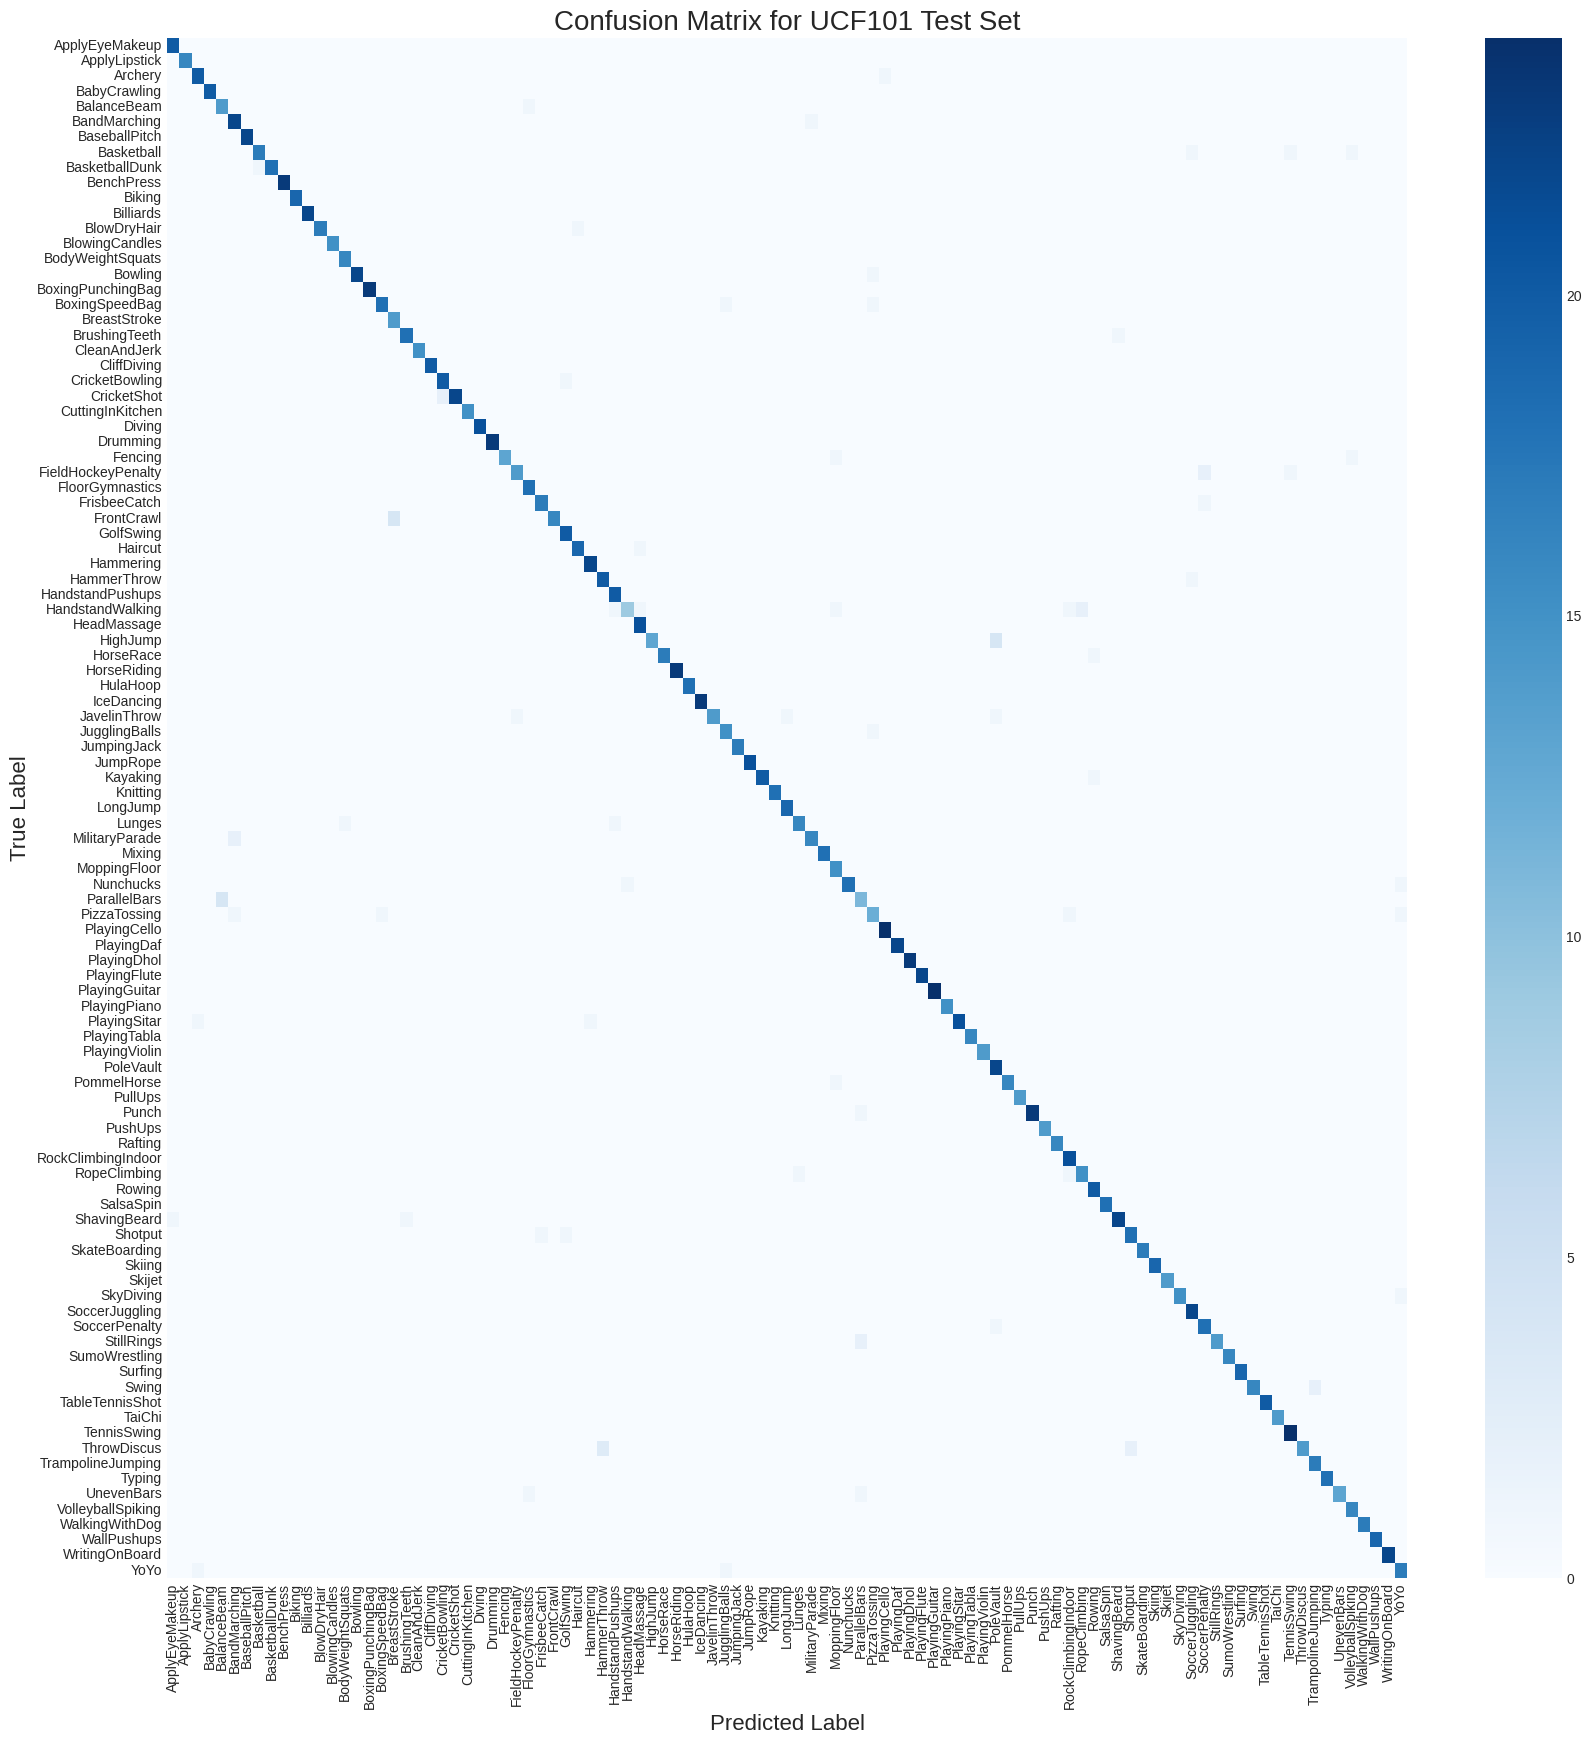

In [ ]:
# --- Analysis: Generating and Plotting the Confusion Matrix ---
print("Generating predictions for the test set to create the confusion matrix...")
model.eval()
all_preds = []
all_labels = []

# Get all predictions and labels from the test set
with torch.no_grad():
    for videos, labels in tqdm(test_loader, desc="Getting Test Predictions"):
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)

        # Get the predicted class index
        predicted = torch.argmax(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=cls_df['class_name'], yticklabels=cls_df['class_name'])
plt.title('Confusion Matrix for UCF101 Test Set', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# --- Analysis: Generating a Detailed Classification Report ---
# Use the predictions and labels generated in the previous cell
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

# Generate and print the report
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("--- Classification Report for Each Class ---")
print(report)

--- Classification Report for Each Class ---
                    precision    recall  f1-score   support

    ApplyEyeMakeup       0.95      1.00      0.98        20
     ApplyLipstick       1.00      1.00      1.00        16
           Archery       0.91      0.95      0.93        21
      BabyCrawling       1.00      1.00      1.00        20
       BalanceBeam       0.78      0.93      0.85        15
      BandMarching       0.88      0.96      0.92        23
     BaseballPitch       1.00      1.00      1.00        22
        Basketball       0.94      0.85      0.89        20
    BasketballDunk       1.00      0.95      0.97        19
        BenchPress       1.00      1.00      1.00        23
            Biking       1.00      1.00      1.00        19
         Billiards       1.00      1.00      1.00        22
       BlowDryHair       1.00      0.94      0.97        18
    BlowingCandles       1.00      1.00      1.00        15
  BodyWeightSquats       0.94      1.00      0.97     

In [ ]:
# --- Analysis: Finding and Visualizing Misclassified Examples ---

# Find indices of misclassified samples
misclassified_indices = [i for i, (pred, true) in enumerate(zip(all_preds, all_labels)) if pred != true]
print(f"Found {len(misclassified_indices)} misclassified videos in the test set.")

# We need an untransformed dataset for clean visualization
vis_test_dataset = UCF101Dataset(test_videos, test_labels, transform=None, frames_per_clip=FRAMES_PER_CLIP)

# Select a few random misclassified samples to display
num_samples_to_show = 3
if len(misclassified_indices) > num_samples_to_show:
    sample_indices = random.sample(misclassified_indices, num_samples_to_show)
else:
    sample_indices = misclassified_indices

print(f"\nDisplaying {len(sample_indices)} misclassified examples...")

for i, test_idx in enumerate(sample_indices):
    print(f"\n--- Misclassified Sample {i+1} ---")

    # Get the raw video clip and scale it for display
    clip_raw, _ = vis_test_dataset[test_idx]
    clip_for_display = clip_raw / 255.0

    # Get true and predicted labels
    true_label_name = idx_to_class[all_labels[test_idx]]
    pred_label_name = idx_to_class[all_preds[test_idx]]

    label_text = f"True Label: {true_label_name} | Predicted Label: {pred_label_name}"
    print(label_text)

    # Display the video
    display(show_video_clip(clip_for_display, label=label_text))

Found 82 misclassified videos in the test set.

Displaying 3 misclassified examples...

--- Misclassified Sample 1 ---
True Label: BlowDryHair | Predicted Label: Haircut



--- Misclassified Sample 2 ---
True Label: ParallelBars | Predicted Label: BalanceBeam



--- Misclassified Sample 3 ---
True Label: PommelHorse | Predicted Label: MoppingFloor


Shape of feature maps from layer1[0]: torch.Size([1, 64, 16, 64, 64])


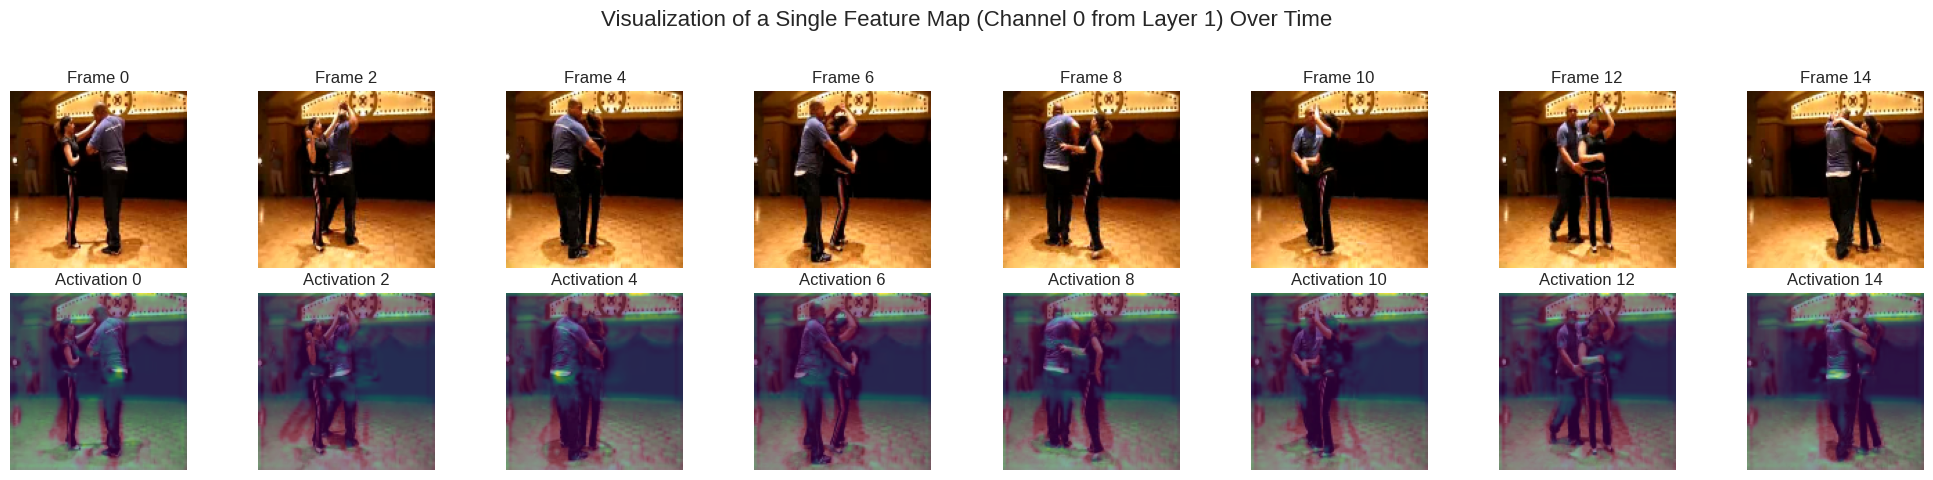

In [ ]:
# --- Visualization of Intermediate Feature Maps ---

# A dictionary to store the activations from our hook
activations = {}

def get_activation(name):
    """A hook function to capture the output of a specific layer."""
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Let's inspect an intermediate layer. `layer1` is a good choice for early features.
# We attach our hook to the first block of layer1.
model.layer1[0].register_forward_hook(get_activation('layer1.0'))

# --- Get a sample video ---
# Use the visualization dataset to get a raw, untransformed clip
vis_dataset = UCF101Dataset(test_videos, test_labels, transform=None, frames_per_clip=FRAMES_PER_CLIP)
clip_raw, label_idx = vis_dataset[random.randint(0, len(vis_dataset)-1)]

# Transform the clip to prepare it for the model
clip_transformed = clip_raw.permute(1, 0, 2, 3)
clip_transformed = val_transform(clip_transformed)
clip_transformed = clip_transformed.permute(1, 0, 2, 3)

# --- Run the model to trigger the hook ---
with torch.no_grad():
    output = model(clip_transformed.unsqueeze(0).to(device))

# --- Retrieve the captured activations ---
# The shape will be (Batch, Channels, Time, Height, Width)
feature_maps = activations['layer1.0'].cpu()
print(f"Shape of feature maps from layer1[0]: {feature_maps.shape}")

# --- Visualize the feature maps ---
# We will visualize one of the feature maps (e.g., the first one) across time
# We select the first feature map (channel 0)
feature_map_channel_0 = feature_maps[0, 0] # Shape: (Time, Height, Width)

# Normalize the feature map for better visualization
fm_min, fm_max = feature_map_channel_0.min(), feature_map_channel_0.max()
feature_map_normalized = (feature_map_channel_0 - fm_min) / (fm_max - fm_min)

# Upsample the feature map to the original image size for overlay
upsample = torch.nn.Upsample(size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
feature_map_upsampled = upsample(feature_map_normalized.unsqueeze(0)).squeeze(0)

# Get the original clip ready for display
clip_for_display = clip_raw / 255.0

# Plot the original frames alongside the feature map heatmaps
num_frames_to_show = 8
fig, axs = plt.subplots(2, num_frames_to_show, figsize=(20, 5))
fig.suptitle(f'Visualization of a Single Feature Map (Channel 0 from Layer 1) Over Time', fontsize=16)

for i in range(num_frames_to_show):
    frame_idx = i * (FRAMES_PER_CLIP // num_frames_to_show)

    # Original Frame
    original_frame = clip_for_display.permute(1, 2, 3, 0)[frame_idx]
    axs[0, i].imshow(original_frame)
    axs[0, i].set_title(f'Frame {frame_idx}')
    axs[0, i].axis('off')

    # Feature Map as Heatmap
    heatmap = feature_map_upsampled[frame_idx]
    axs[1, i].imshow(original_frame)
    axs[1, i].imshow(heatmap, cmap='viridis', alpha=0.6)
    axs[1, i].set_title(f'Activation {frame_idx}')
    axs[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

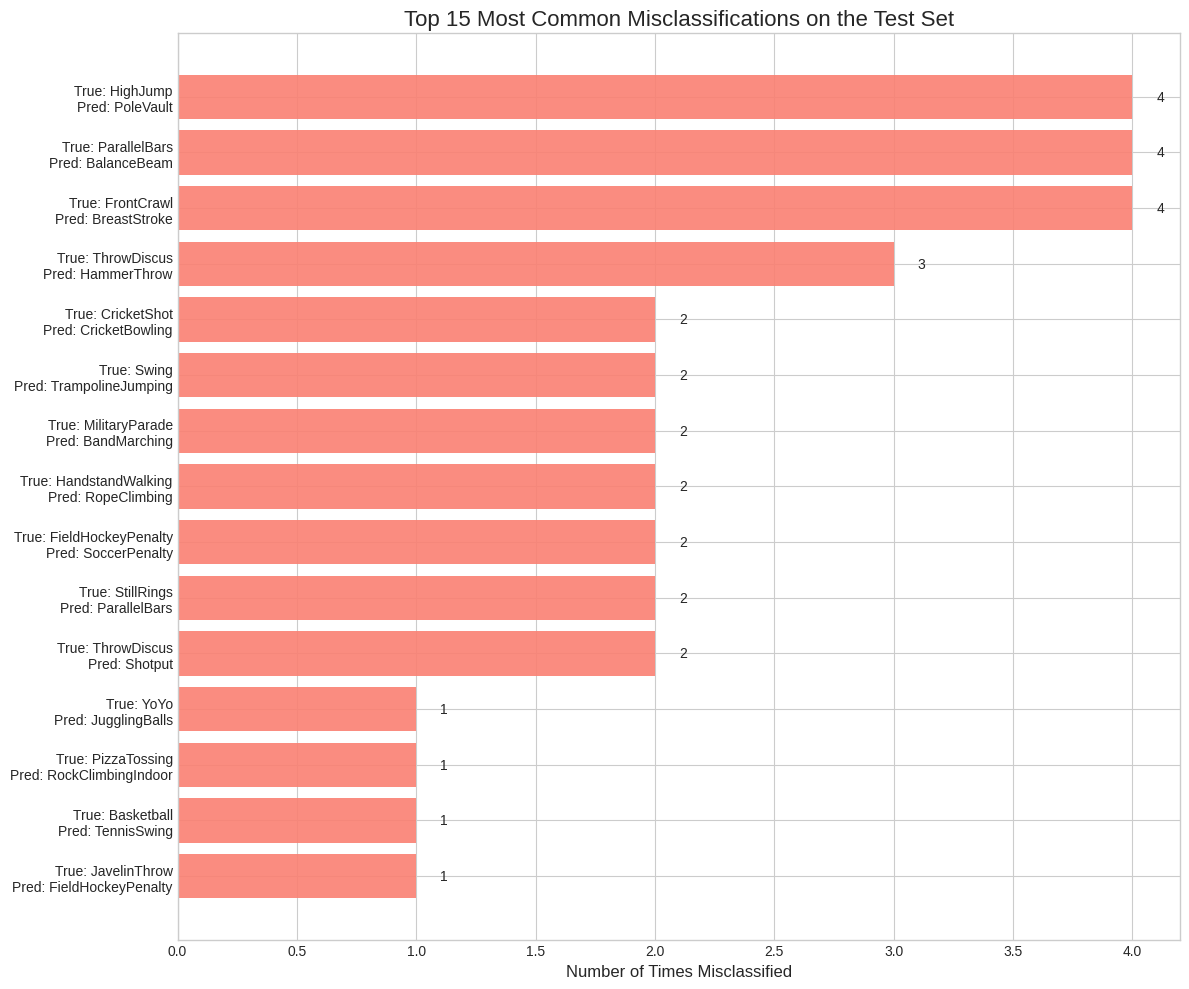

In [ ]:
import collections

# --- Analysis: Finding and Plotting the Most Common Misclassifications ---

# This assumes 'all_labels' and 'all_preds' were generated in the confusion matrix cell.
# If not, we regenerate them here for completeness.
if 'all_preds' not in locals() or 'all_labels' not in locals():
    print("Generating predictions for the test set...")
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for videos, labels in tqdm(test_loader, desc="Getting Test Predictions"):
            videos, labels = videos.to(device)
            outputs = model(videos)
            predicted = torch.argmax(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

# Find all instances where the prediction was incorrect
misclassifications = []
for true_label_idx, pred_label_idx in zip(all_labels, all_preds):
    if true_label_idx != pred_label_idx:
        true_class_name = idx_to_class[true_label_idx]
        pred_class_name = idx_to_class[pred_label_idx]
        misclassifications.append(f"True: {true_class_name}\nPred: {pred_class_name}")

# Count the occurrences of each unique misclassification pair
top_errors = collections.Counter(misclassifications).most_common(15) # Get the top 15 errors

# --- Plot the results ---
if top_errors:
    # Separate the labels and counts for plotting
    error_labels, error_counts = zip(*top_errors)

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 10))

    # Create a horizontal bar chart
    bars = plt.barh(range(len(error_labels)), error_counts, color='salmon', alpha=0.9)

    # Set plot properties
    plt.yticks(range(len(error_labels)), error_labels)
    plt.gca().invert_yaxis() # Display the most common error at the top
    plt.xlabel('Number of Times Misclassified', fontsize=12)
    plt.title('Top 15 Most Common Misclassifications on the Test Set', fontsize=16)

    # Add counts on the bars
    for bar in bars:
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', ha='left')

    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found on the test set!")

Analyzing temporal confidence for a sample video...


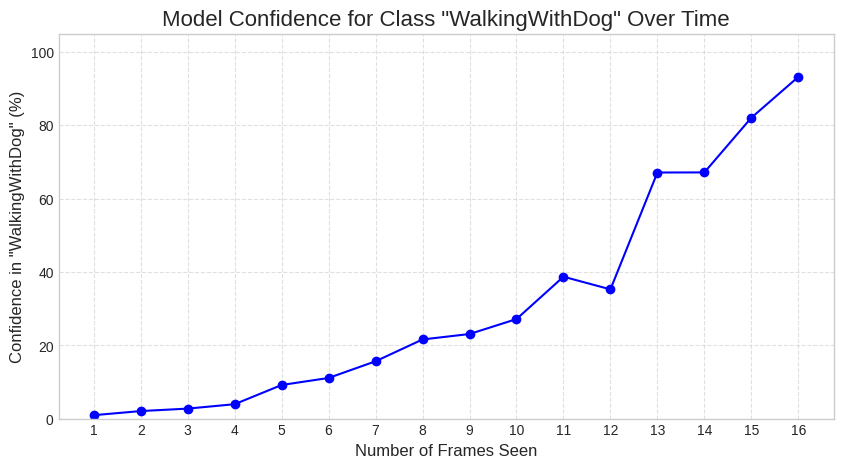

In [ ]:
# --- Visualization of Prediction Confidence for Each Frame ---

def plot_confidence_over_time(model, video_clip, true_label_idx, device):
    """
    Performs inference on accumulating frames of a clip and plots the confidence
    for the true label over time.
    """
    model.eval()

    true_label_name = idx_to_class[true_label_idx.item()]
    confidences = []

    # We will feed the model an increasing number of frames
    for i in range(1, FRAMES_PER_CLIP + 1):
        # Take the first 'i' frames of the clip
        partial_clip = video_clip[:, :i, :, :]

        # The model expects a fixed size of FRAMES_PER_CLIP. We pad the rest.
        # Create a padded tensor
        padded_clip = torch.zeros_like(video_clip)
        padded_clip[:, :i, :, :] = partial_clip

        with torch.no_grad():
            output = model(padded_clip.unsqueeze(0).to(device))
            probs = F.softmax(output, dim=1).cpu().squeeze()

            # Get the confidence for the correct class
            confidence_for_true_label = probs[true_label_idx].item()
            confidences.append(confidence_for_true_label * 100)

    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, FRAMES_PER_CLIP + 1), confidences, marker='o', linestyle='-', color='b')
    plt.title(f'Model Confidence for Class "{true_label_name}" Over Time', fontsize=16)
    plt.xlabel('Number of Frames Seen', fontsize=12)
    plt.ylabel(f'Confidence in "{true_label_name}" (%)', fontsize=12)
    plt.ylim(0, 105)
    plt.xticks(range(1, FRAMES_PER_CLIP + 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- Select a random video from the test set and run the analysis ---
# Re-using the 'clip_transformed' and 'label_idx' from the Grad-CAM cell.
# Make sure that cell has been run recently.
print("Analyzing temporal confidence for a sample video...")
plot_confidence_over_time(model, clip_transformed, label_idx, device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


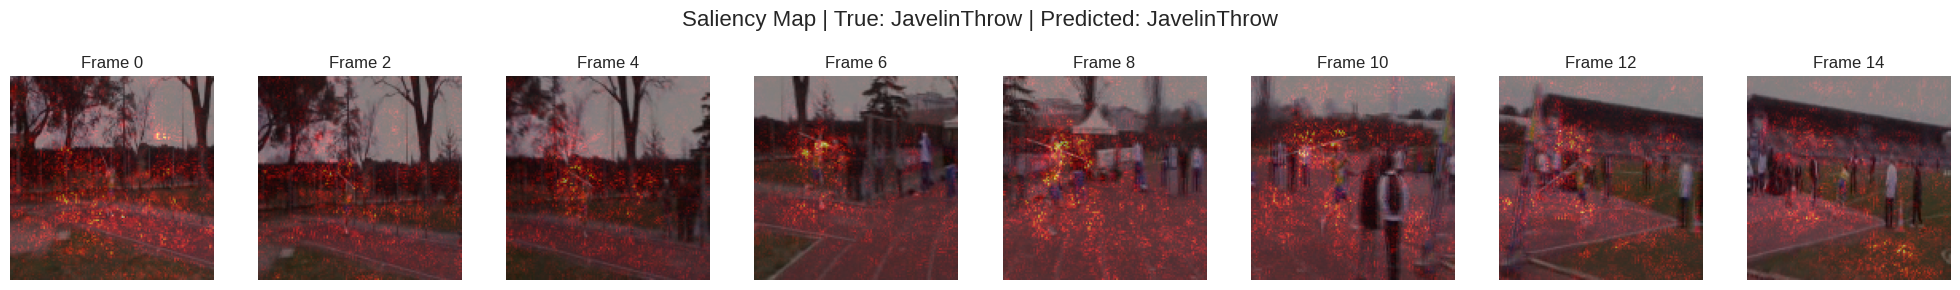

In [ ]:
# --- Visualization of Saliency Maps ---
# the saliency map helps us understand the model's decisiion-making process
# highlights the specific pixels in the input video that the model considered most important for maing its final prediction

# Get a sample video clip
clip_raw, label_idx = vis_dataset[random.randint(0, len(vis_dataset)-1)]
clip_transformed = val_transform(clip_raw.permute(1, 0, 2, 3)).permute(1, 0, 2, 3)
clip_for_model = clip_transformed.unsqueeze(0).to(device)
clip_for_model.requires_grad = True # IMPORTANT: We need gradients for the input

# --- Calculate Saliency ---
model.eval()
output = model(clip_for_model)

# Get the score for the predicted class
pred_score, pred_idx = torch.max(output, 1)

# Backpropagate the score to the input
pred_score.backward()

# Get the gradients and take the absolute maximum value across channels
saliency, _ = torch.max(clip_for_model.grad.data.abs(), dim=1)
saliency = saliency.squeeze(0).cpu() # Shape (T, H, W)

# --- Visualize the Saliency Maps ---
clip_for_display = clip_raw / 255.0

fig, axs = plt.subplots(1, 8, figsize=(20, 3))
true_label_name = idx_to_class[label_idx.item()]
pred_label_name = idx_to_class[pred_idx.item()]
fig.suptitle(f'Saliency Map | True: {true_label_name} | Predicted: {pred_label_name}', fontsize=16)

for i in range(8):
    frame_idx = i * (FRAMES_PER_CLIP // 8)

    original_frame = clip_for_display.permute(1, 2, 3, 0)[frame_idx]
    heatmap = saliency[frame_idx]

    axs[i].imshow(original_frame)
    axs[i].imshow(heatmap, cmap='hot', alpha=0.5)
    axs[i].set_title(f'Frame {frame_idx}')
    axs[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

I implemented a two-phase training approach to fine-tune the pretrained 3D ResNet model.

**Phase 1:** classifier head training, with the objective to train only the final classification layer of the model. This phase rapidly adapted the model to  the new dataset, achieving a validation accuracy of 88.4% in 2 epochs.

**Phase 2:** full model fine-tuning, to unfreeze all laayers and fine-tune the entire model. The learning rate in this case was lower by to orders of magnitude (1e-5)  to make subtle adjustments. This phase, trained for 3 epochs, further improved the model's performance with a peak validation accuracy of 95.4%.

# Metrics analysis
**Accuracy**: answers the question "out of all the predictions the model made, what percentage was correct?". The model's test accuracy of 95.70% is a strong starting point, as it tells us that the model correctly identified the action in a video clip about 96 out of 100 times.

**Precision**: "when the model predicted a specific action, how often was it correct?", measures exactness. The model's precision of 95.89% is excellent. It means that when the model identifies a video as "playing cello," for example, it is correct about 96% of the time. This is important for trust; you can be confident that the model's positive identifications are reliable and not just random guesses. It helps minimize "false positives" (e.g., labeling a "violin" video as "cello")

**Recall**: "Of all the actual instances of a specific action, how many did the model successfully find?" It's a measure of completeness. The model's recall of 95.48% shows that it's very good at finding all the videos of a certain class. It successfully identified about 95.5% of all the actual "playing cello" videos in the test set. This is crucial for applications where you cannot afford to miss instances of an event, helping to minimize "false negatives" (e.g., failing to identify a "cello" video and calling it something else).

For this specific task of general human action classification, the **F1-Score** is the most important single metric, because in a dataset like UCF101, which has 101 different actions, there isn't one "critical" action to find. The goal is a model that performs reliably across all categories, and this balanced is represented by the F1 score. In our case, the F1-score is satisfactory (95.49%).

What would happen with other metrics?
- High-Precision, Low-Recall Model: This model is very cautious. It will only label a video as "Playing Cello" if it's absolutely certain.
  - Pro: When it says "Cello," it's almost always right (high precision).
  - Con: It might miss many other cello videos because it wasn't confident enough, labeling them as something else or "unknown" (low recall).

- High-Recall, Low-Precision Model: This model is very eager. It labels any video that has a stringed instrument as "Playing Cello."
  - Pro: It successfully finds almost every single cello video (high recall).
  - Con: It also incorrectly labels many violin and viola videos as "Cello" (low precision).

Neither of these scenarios is ideal. We want a model that is both confident in its predictions and doesn't miss many examples.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (50%)**
   - Proper 3D ResNet model setup and fine-tuning
   - Correct video data preprocessing and dataset implementation
   - Working training loop with validation
   - Appropriate loss function and optimizer usage

2. **Model Performance (25%)**
   - Reasonable classification metrics (Accuracy, Precision, Recall, F1)
   - Convergence during training
   - Generalization to test set

3. **Code Quality (25%)**
   - Clean, readable code with proper structure
   - Efficient video processing implementation
   - Good coding practices and documentation

# Created by: Hassan Alsayhah